In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [78]:
# Taxis
df = pd.read_csv('results/taxi_diff_models_sample.csv')

df['ts'] = pd.to_datetime(df['ts'])

df.head(10)

,Unnamed: 0,ts,actual,district,MEAN,ARF,HTR,SRP
0,0,2016-03-04 19:30:30,728,Manhattan,0.000000,0.000000,0.000000,0.000000
1,1,2016-03-04 19:30:48,724,Manhattan,728.000000,87.360000,14.560000,728.000000
2,2,2016-03-04 19:30:50,249,Manhattan,726.000000,726.000000,726.000000,726.047397
3,3,2016-03-04 19:30:56,724,Manhattan,567.000000,567.488889,567.000000,568.594014
4,4,2016-03-04 19:30:59,331,Manhattan,606.250000,610.464138,606.250000,605.047218
5,5,2016-03-04 19:31:04,854,Manhattan,551.200000,546.058824,551.200000,551.917973
6,6,2016-03-04 19:31:24,389,Manhattan,601.666667,604.777240,601.666667,603.586694
7,7,2016-03-04 19:31:34,201,Manhattan,571.285714,575.030844,571.285714,571.159088
8,8,2016-03-04 19:31:37,601,Manhattan,525.000000,509.538889,525.000000,521.093210
9,9,2016-03-04 19:31:51,273,Manhattan,533.444444,524.142857,533.444444,535.951721


9597


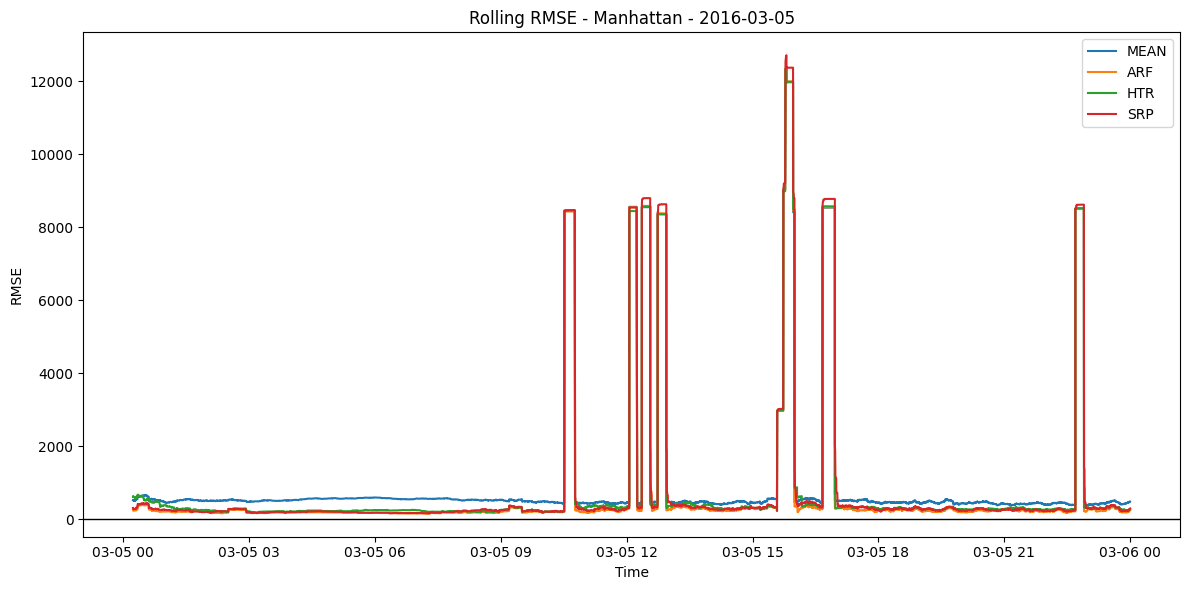

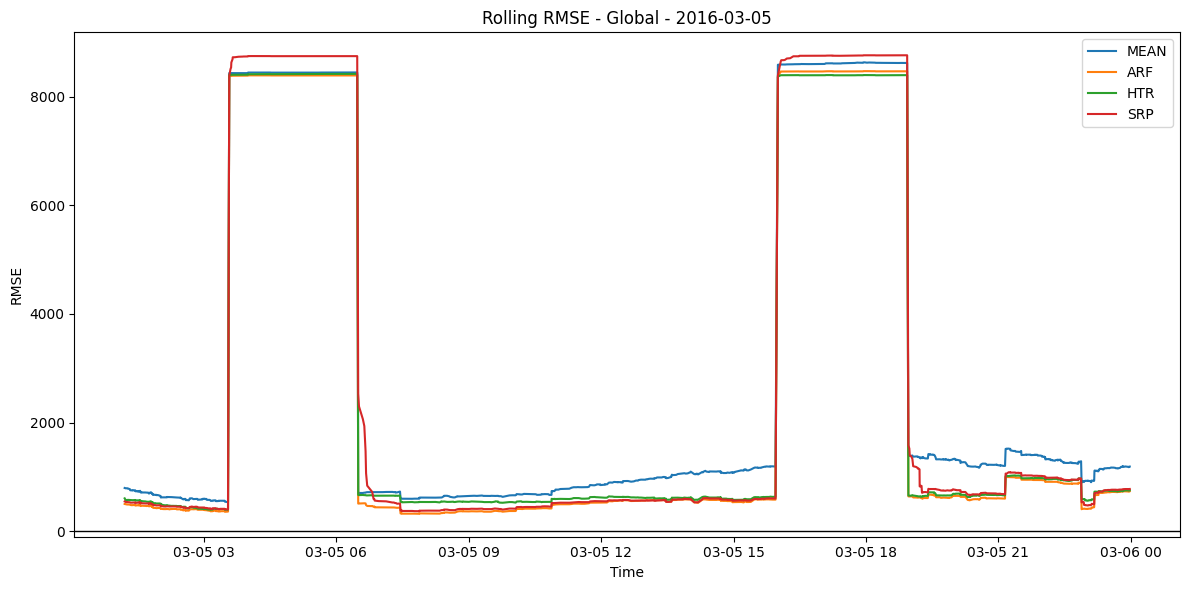

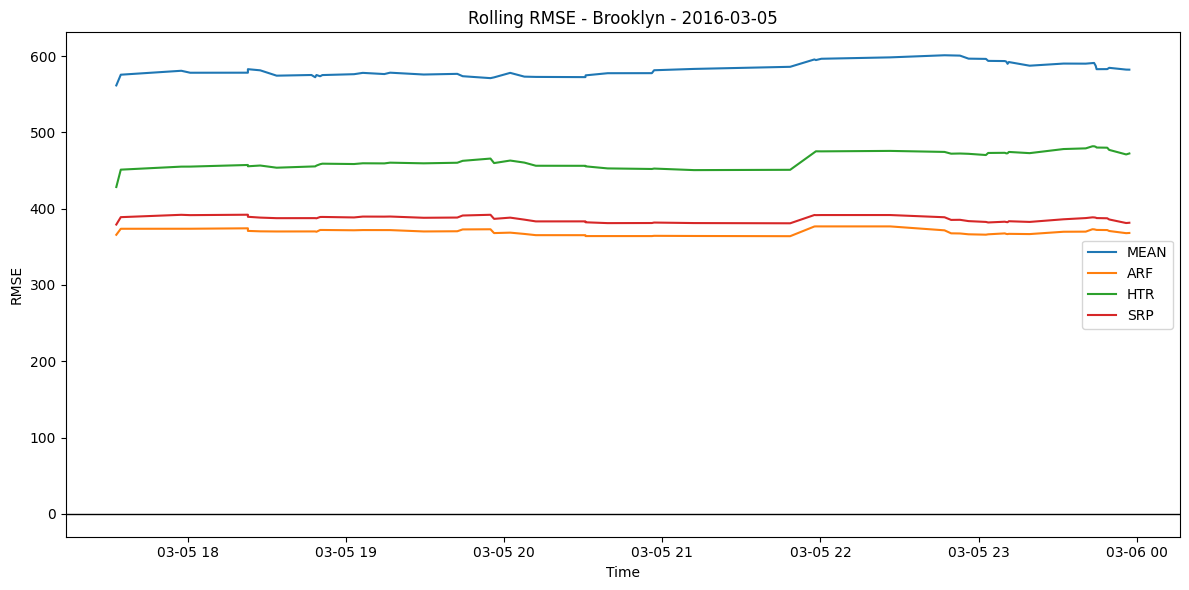

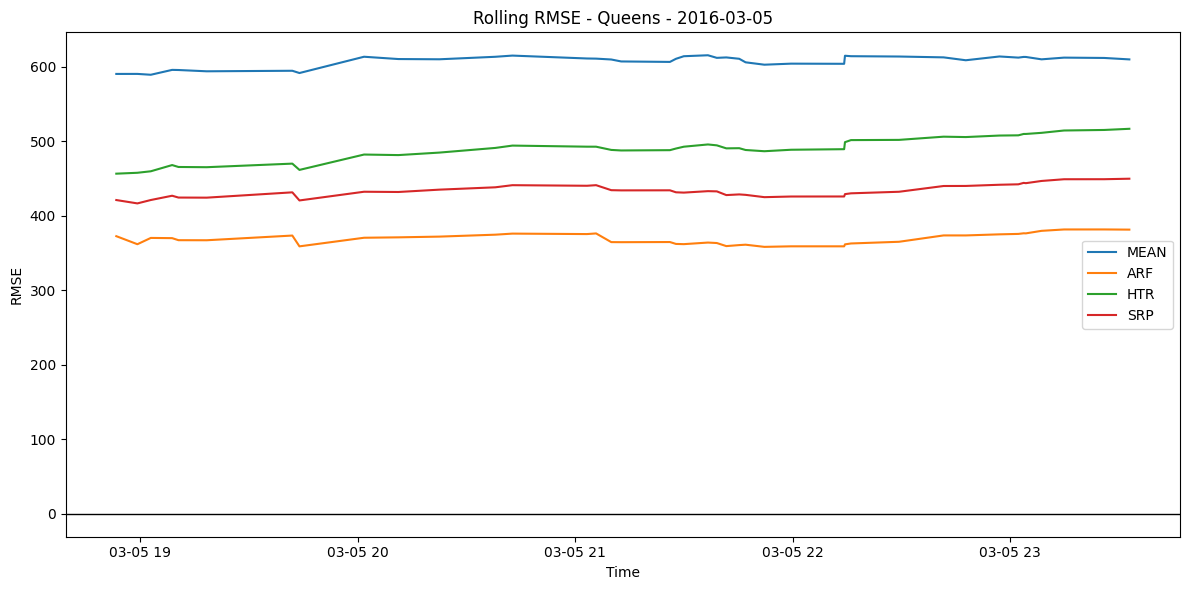

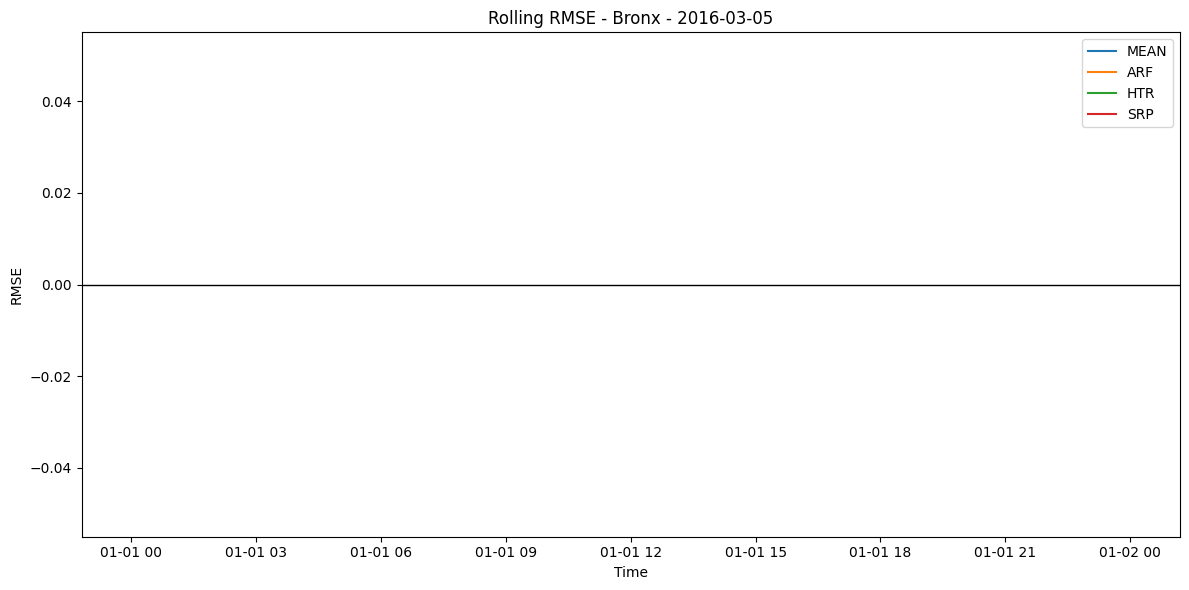

In [80]:
target_day = pd.Timestamp("2016-03-05").date()
df = df[df["ts"].dt.date == target_day].copy()

print(len(df))

window = 100
models = ['MEAN', 'ARF', 'HTR', 'SRP']

districts = df['district'].unique()

for d in districts:
    df_d = df[df['district'] == d].copy()
    
    plt.figure(figsize=(12,6))
    
    for m in models:
        df_d[f'sq_err_{m}'] = (df_d['actual'] - df_d[m]) ** 2
        
        df_d[f'roll_{m}'] = df_d[f'sq_err_{m}'].rolling(window).mean() ** 0.5
        
        plt.plot(df_d['ts'], df_d[f'roll_{m}'], label=m)
    
    plt.title(f"Rolling RMSE - {d} - {target_day}")
    plt.xlabel("Time")
    plt.ylabel("RMSE")
    # plt.yscale('log')
    plt.axhline(0, color='black', linewidth=1)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'plots/taxi_{d}.jpg')
    plt.show()

In [38]:
# Synth
df = pd.read_csv('dataset/warsaw_osm_network_stream.csv')
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values('timestamp')

res_df = pd.read_csv('results/synth_all.csv')
res_df = res_df.drop('Unnamed: 0', axis=1)
res_df.head(10)

,ts,actual,MEAN,ARF,HTR,SRP
0,0,25.131083,0.000000,0.000000,0.000000,0.000000
1,1,11.619191,25.131083,3.015730,0.502622,25.131083
2,2,55.764620,18.375137,4.898974,0.909696,18.535243
3,3,19.220696,30.838298,30.314376,30.838298,30.780777
4,4,42.313451,27.933898,27.798278,27.933898,28.072133
5,5,17.288726,30.809808,31.072693,30.809808,30.777945
6,6,21.631542,28.556295,28.650621,28.556295,28.063298
7,7,50.180485,27.567044,27.961466,27.567044,25.698920
8,8,17.467685,30.393724,30.254037,30.393724,30.084523
9,9,26.735606,28.957498,29.337531,28.957498,28.706693


In [39]:
mask = (
    (df["timestamp"].dt.year == 2025) &
    (df["timestamp"].dt.month == 4) &
    (df["timestamp"].dt.day == 24)
)

df_filtered = df.loc[mask]
idx = df_filtered.index
pos_idx = df.index.get_indexer(idx)
res_filtered = res_df.loc[idx]
print(len(res_filtered))

845


In [40]:
res_df.columns

Index(['ts', 'actual', 'MEAN', 'ARF', 'HTR', 'SRP'], dtype='object')

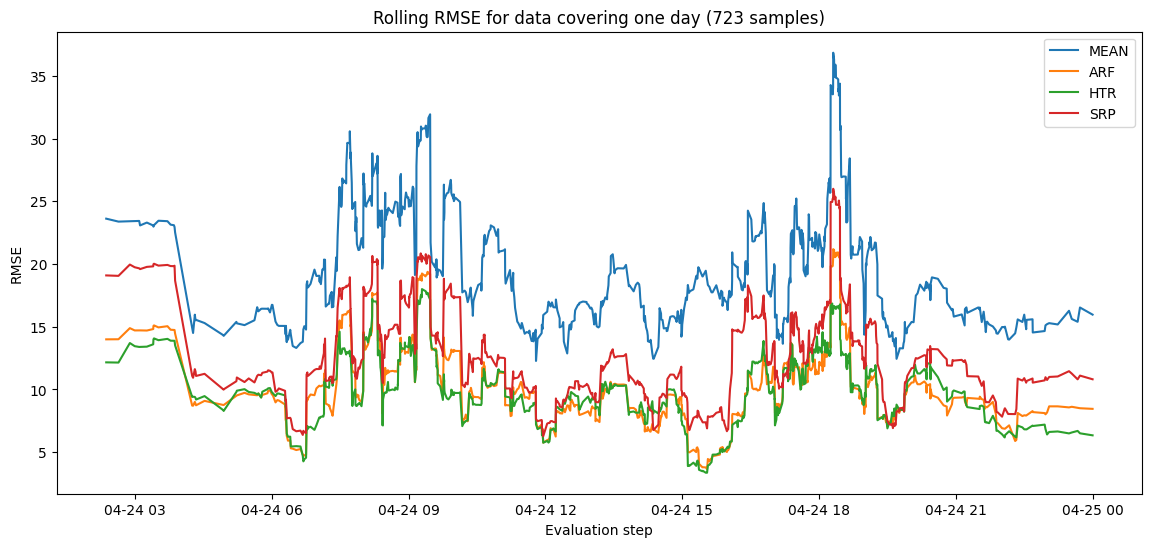

In [41]:
window = 20

models = [c for c in res_df.columns if c not in ["ts", "actual", "LIN"]]

rmse_df = res_df.copy().loc[idx]

for m in models:
    rmse_df[m] = np.sqrt(((rmse_df["actual"] - rmse_df[m]) ** 2).rolling(window).mean())
    # rmse_df[m] = np.sqrt(((np.log1p(rmse_df["actual"]) - np.log1p(rmse_df[m])) ** 2).rolling(window).mean())

plt.figure(figsize=(14, 6))

for m in models:
    plt.plot(df["timestamp"].loc[idx], rmse_df[m], label=m)

plt.title(f"Rolling RMSE for data covering one day (723 samples)")
plt.xlabel("Evaluation step")
plt.ylabel("RMSE")
plt.legend()


plt.savefig('plots/synth_14_04.jpg')

plt.show()